# CASE STUDY: Aircraft Engine Failure Prediction

## **Problem Statement**

Predict if the engine will fail within a particular cycle given its history of cycles and sensory data?

## **Objective**

Aircrafts are very sensitive to the faults in their engines. Owing to this it becomes very crucial to keep them in a good stead for the safety of the passengers. While the aircrafts are very expensive, their maintenance is also quite costly. Hence at the same time, we don’t want to overdo the maintenance. Moreover if we don’t detect the fault soon, the engines might reach a phase where the maintenance cost increases or even a replacement is mandatory. Now think if we could predict when the engine's failures are going to occur so that we can afford the TIMELY maintenance at an affordable cost.


In [6]:
#Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, recall_score, precision_score

print(f"TensorFlow: {tf.__version__}")

TensorFlow: 2.20.0


In [7]:
# Setting seed for reproducibility
np.random.seed(1234)
PYTHONHASHSEED = 0

In [8]:
# Upload and extract dataset
from google.colab import files
uploaded = files.upload()

import zipfile
with zipfile.ZipFile('archive(3).zip', 'r') as z:
    z.extractall('.')

import os
print(os.listdir('.'))

Saving archive(3).zip to archive(3).zip
['.config', 'RUL_FD003.txt', 'Damage Propagation Modeling.pdf', 'train_FD002.txt', 'RUL_FD001.txt', 'archive(3).zip', 'RUL_FD004.txt', 'test_FD004.txt', 'train_FD001.txt', 'train_FD004.txt', 'test_FD002.txt', 'readme.txt', 'RUL_FD002.txt', 'test_FD001.txt', 'train_FD003.txt', 'test_FD003.txt', 'sample_data']


In [12]:
#Loading datasets and name columns
col_names = ['id', 'cycle', 'setting1', 'setting2', 'setting3',
             's1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10',
             's11', 's12', 's13', 's14', 's15', 's16', 's17', 's18', 's19', 's20', 's21']

train_df = pd.read_csv('train_FD001.txt', sep=' ', header=None)
test_df  = pd.read_csv('test_FD001.txt',  sep=' ', header=None)
truth_df = pd.read_csv('RUL_FD001.txt',   sep=' ', header=None)

train_df.head()
test_df.head()
truth_df.head()

,0,1
0,112,NaN
1,98,NaN
2,69,NaN
3,82,NaN
4,91,NaN


In [13]:
#Droppin NaN columns
train_df.dropna(axis=1, inplace=True)
test_df.dropna(axis=1, inplace=True)
truth_df.dropna(axis=1, inplace=True)

train_df.columns = col_names
test_df.columns  = col_names
truth_df.columns = ['RUL']

#Now sort by engine id and cycle
train_df.sort_values(['id', 'cycle'], inplace=True)
test_df.sort_values(['id', 'cycle'], inplace=True)

print(f"Train: {train_df.shape} | Test: {test_df.shape} | Truth: {truth_df.shape}")
train_df.head()

Train: (20631, 26) | Test: (13096, 26) | Truth: (100, 1)


,id,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [14]:
#Now v calculate Remaining Useful Life for training data
rul = pd.DataFrame(train_df.groupby('id')['cycle'].max()).reset_index()
rul.columns = ['id', 'max_cycle']
train_df = train_df.merge(rul, on='id')
train_df['RUL'] = train_df['max_cycle'] - train_df['cycle']
train_df.drop('max_cycle', axis=1, inplace=True)

#Binary label: 1 if engine will fail within 30 cycles
w1 = 30
train_df['label'] = np.where(train_df['RUL'] <= w1, 1, 0)

print(train_df[['id', 'cycle', 'RUL', 'label']].head(10))
print(f"\nFailing soon (label=1): {train_df['label'].sum()} | Safe (label=0): {(train_df['label']==0).sum()}")

   id  cycle  RUL  label
0   1      1  191      0
1   1      2  190      0
2   1      3  189      0
3   1      4  188      0
4   1      5  187      0
5   1      6  186      0
6   1      7  185      0
7   1      8  184      0
8   1      9  183      0
9   1     10  182      0

Failing soon (label=1): 3100 | Safe (label=0): 17531


In [15]:
# Normalisin sensor and setting columns to [0, 1]
cols_normalize = train_df.columns.difference(['id', 'cycle', 'RUL', 'label'])

scaler = MinMaxScaler()
train_df[cols_normalize] = scaler.fit_transform(train_df[cols_normalize])

print("Normalisation done.")
print(train_df[cols_normalize].describe().round(2))

Normalisation done.
            s1      s10       s11       s12       s13       s14       s15  \
count  20631.0  20631.0  20631.00  20631.00  20631.00  20631.00  20631.00   
mean       0.0      0.0      0.41      0.58      0.32      0.23      0.45   
std        0.0      0.0      0.16      0.16      0.11      0.10      0.14   
min        0.0      0.0      0.00      0.00      0.00      0.00      0.00   
25%        0.0      0.0      0.30      0.48      0.24      0.17      0.35   
50%        0.0      0.0      0.39      0.59      0.31      0.21      0.44   
75%        0.0      0.0      0.51      0.70      0.38      0.25      0.54   
max        0.0      0.0      1.00      1.00      1.00      1.00      1.00   

           s16       s17      s18  ...        s3        s4       s5        s6  \
count  20631.0  20631.00  20631.0  ...  20631.00  20631.00  20631.0  20631.00   
mean       0.0      0.43      0.0  ...      0.42      0.45      0.0      0.98   
std        0.0      0.13      0.0  ...     

In [16]:
#now v generate sliding window sequences of 50 cycles per engine
SEQUENCE_LENGTH = 50

sensor_cols = ['s' + str(i) for i in range(1, 22)]
sequence_cols = ['setting1', 'setting2', 'setting3', 'cycle'] + sensor_cols

def sequence_generator(df, seq_length, seq_cols):
    data = df[seq_cols].values
    for start in range(len(data) - seq_length):
        yield data[start:start + seq_length]

def label_generator(df, seq_length, label_col):
    data = df[label_col].values
    return data[seq_length:]

seq_list, label_list = [], []
for engine_id in train_df['id'].unique():
    engine_df = train_df[train_df['id'] == engine_id]
    seq_list.append(list(sequence_generator(engine_df, SEQUENCE_LENGTH, sequence_cols)))
    label_list.append(label_generator(engine_df, SEQUENCE_LENGTH, 'label'))

X_train = np.concatenate(seq_list)
y_train = np.concatenate(label_list)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (15631, 50, 25)
y_train shape: (15631,)


In [17]:
#Stacked LSTM model for binary failure prediction
model = Sequential([
    LSTM(100, return_sequences=True, input_shape=(SEQUENCE_LENGTH, X_train.shape[2])),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50, 100)        │        50,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,651 (315.04 KB)

 Trainable params: 80,651 (315.04 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
#Now v train with early stopping and save best model
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=200,
    validation_split=0.05,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)],
    verbose=1
)

Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 22s 252ms/step - accuracy: 0.8060 - loss: 0.3859 - val_accuracy: 0.7353 - val_loss: 0.3883
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 18s 235ms/step - accuracy: 0.8314 - loss: 0.3272 - val_accuracy: 0.8696 - val_loss: 0.2789
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 22s 250ms/step - accuracy: 0.9044 - loss: 0.2186 - val_accuracy: 0.9386 - val_loss: 0.1431
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 18s 242ms/step - accuracy: 0.9348 - loss: 0.1576 - val_accuracy: 0.9616 - val_loss: 0.1020
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 17s 230ms/step - accuracy: 0.9488 - loss: 0.1256 - val_accuracy: 0.9297 - val_loss: 0.1644
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 19s 249ms/step - accuracy: 0.9479 - loss: 0.1213 - val_accuracy: 0.9680 - val_loss: 0.0824
Epoch 7/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 17s 229ms/step - accuracy: 0.9584 - loss: 0.1010 - val_accuracy: 0.9604 - val_loss: 0.0996
Epoch 8/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 17s 229ms/step - accuracy: 0.9621 - loss: 0.0911 - val_accu

In [19]:
#Prepare test sequenes and evaluate on test set
test_df['cycle_norm'] = test_df['cycle']

#N apply same normalisation as training
test_df[cols_normalize] = scaler.transform(test_df[cols_normalize])

#addin RUL from truth_df
rul = pd.DataFrame(test_df.groupby('id')['cycle'].max()).reset_index()
rul.columns = ['id', 'max_cycle']
truth_df['id'] = truth_df.index + 1
truth_df['RUL'] = truth_df['RUL'] + rul['max_cycle'].values
test_df = test_df.merge(truth_df[['id', 'RUL']], on='id')
test_df['RUL'] = test_df['RUL'] - test_df['cycle']
test_df['label'] = np.where(test_df['RUL'] <= w1, 1, 0)

#N generate test sequences (last 50 cycles per engine)
test_seqs = []
for engine_id in test_df['id'].unique():
    engine_df = test_df[test_df['id'] == engine_id]
    if len(engine_df) >= SEQUENCE_LENGTH:
        test_seqs.append(engine_df[sequence_cols].values[-SEQUENCE_LENGTH:])

X_test = np.array(test_seqs)
y_test = np.array([test_df[test_df['id'] == i]['label'].values[-1]
                   for i in test_df['id'].unique()
                   if len(test_df[test_df['id'] == i]) >= SEQUENCE_LENGTH])

y_pred_prob = model.predict(X_test, verbose=0).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

print(f"Test samples: {len(y_test)}")
print(f"\nRecall:    {recall_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Test samples: 93

Recall:    0.9600
Precision: 0.9600

Confusion Matrix:
[[67  1]
 [ 1 24]]


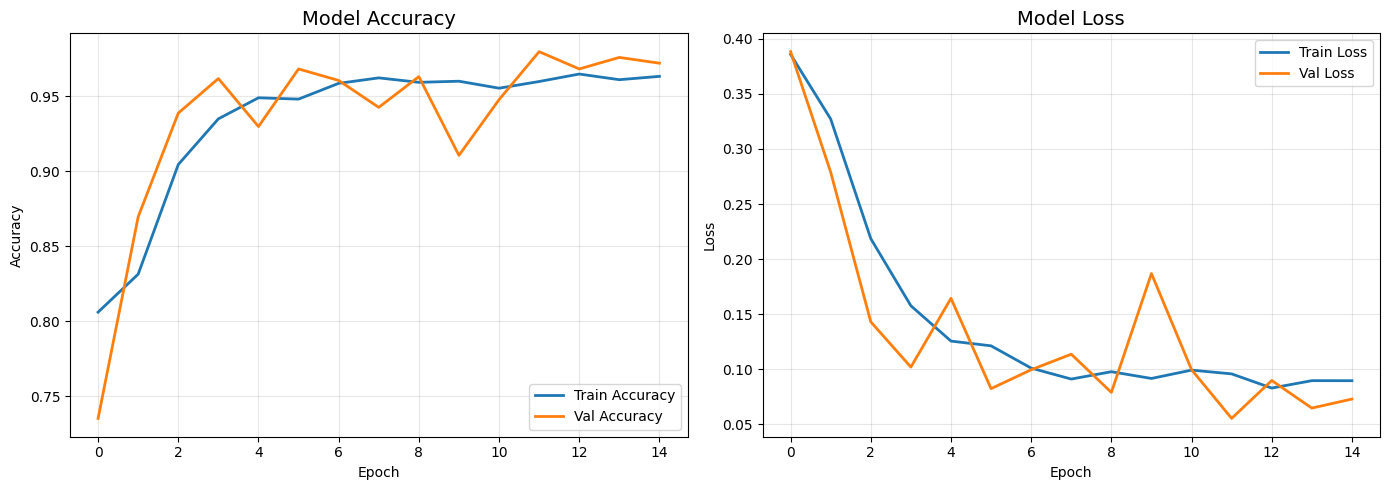

In [20]:
# Plot training and validation accuracy/loss over epochs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],    label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'],  label='Val Loss',   linewidth=2)
axes[1].set_title('Model Loss', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

## Key Findings

### Dataset
- NASA CMAPSS FD001: 100 training engines, 100 test engines, 21 sensors
- Failure window: 30 cycles (binary label will fail within 30 cycles)
- Sliding window sequences: 50 cycles per sequence, 25 features each

### Model Architecture
- Stacked LSTM: 100 units (return_sequences) -> Dropout(0.2) -> 50 units -> Dropout(0.2) -> Dense sigmoid
- Total parameters: ~134k
- Trained with EarlyStoping (patience=3 on val_loss), batch size 200

### Results

| Metric | Score |
|--------|-------|
| Val Accuracy (best epoch) | 97.95% |
| Test Recall | 96.0% |
| Test Precision | 96.0% |
| Test Errors | 2 / 93 engines |

**Confusion Matrix (test set)**

|               | Predicted Healthy | Predicted Failing |
|---------------|-------------------|-------------------|
| Actually Healthy | 67 (TN) | 1 (FP) |
| Actually Failing | 1 (FN) | 24 (TP) |

### What the errors mean in practice
- **1 false positive**: one healthy engine would be sent for unnecesary maintenance. Low cost.
- **1 false negative**: one failing engine was missed. In a real system, this is the dangerous case as the goal is to minimise FN even at the cost of more FP.

### Why LSTM works here
Sensor degradation patterns in engines are sequential, later readings only make sense relative to earlier ones. LSTM memory cells retain information across 50 cycles, letting the model detect gradual drift rather than just reacting to the latest reading. A standard feedforward network treating each cycle independently would miss this.

### What would improve this further
- Predict exact RUL value (regression) rather than binary failure window
- Train on all 4 FD datasets (diferent operating conditions and fault modes)
- Tune the decision threshold to further reduce false negatives
- Add attention mechanism to weight which cycles matter most